In [169]:
import pickle

import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

### Basin wise visualization

In [170]:
strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [171]:
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]
lamah_gdf.sort_index(ascending=True, inplace=True)

In [172]:
potential_attributes = [
	#geomorph - unargueable
	"area_calc", # how much water is available *
	"elev_mean", # how much snow, how much energy *
	"elev_ran", # how variable is the catchment
	"slope_mean", # energy of surface runoff *(since mountains)

	#precipitation
	"p_mean", # influx *
	"et0_mean", # outflux *
	"arid_1", # there are some arid catchments (more et0 than p_mean)
	"p_season", # encode seasonal pattern *
	"hi_prec_fr", # how often do high prec events occur (days/yr with p > 5*p_mean) *
	"hi_prec_du", #*
	"lo_prec_fr", # how often do low prec events occur (days/yr with p < 1 mm/d) *
	"lo_prec_du", #*
	"frac_snow", # essential in mountainous catchments *

    #land cover - nice, since they are accurate over the catchment, and not averaged
	"agr_fra", # 
	"bare_fra", # 
	"forest_fra", # storage
	"glac_fra", # super rare case, and then not that important 
	"lake_fra", # storage, also quite rare
	"urban_fra", # * versieglung, an proxy for disturbance of natural waterways

	#vegetation - represent water storage, and also differences between summer and winter - choose lai or ndvi, since they are correlated. And lai also has some info, about how many layers of vegetation there are. 
	"lai_max", 
	"lai_diff",
	"gvf_max",
	"gvf_diff",

	#soil - represent storage and also percolation speed
	"bedrk_dep", #*
	"soil_poros", #*
	"soil_condu", #*
	"sand_fra", #*
	"silt_fra", #*
	"clay_fra" #*
	]

In [173]:
with open("/home/wuhlmann/BA/data/processed_data/evaluation/q_pred_landcover_0903_135428_domain_metrics.p", "rb") as f: 
	domain_metrics = pickle.load(f)
	
for period in domain_metrics.keys():
	
	for basin_id in domain_metrics[period].keys():
		lamah_gdf.loc[int(basin_id), "period"] = period
		lamah_gdf.loc[int(basin_id), "NSE"] = domain_metrics[period][basin_id]["1D"]["NSE"]

In [174]:
train_set = lamah_gdf[lamah_gdf.period == "train"]
val_set = lamah_gdf[lamah_gdf.period == "validation"]
test_set =lamah_gdf[lamah_gdf.period == "test"]

set_dict = {"train":train_set, "val": val_set, "test": test_set}

<Axes: >

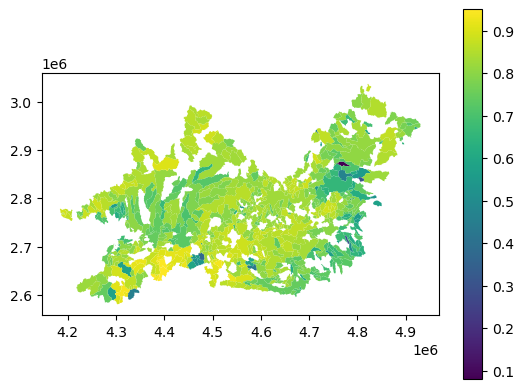

In [175]:
train_set.plot("NSE", legend=True)

<Axes: >

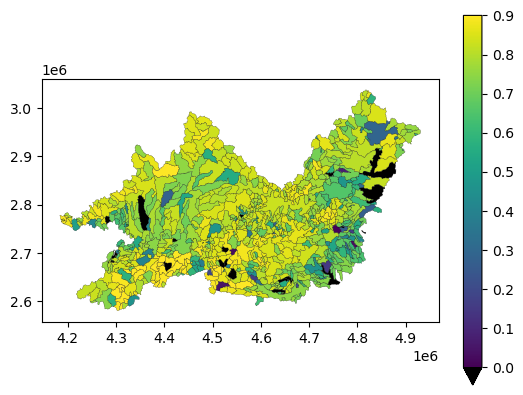

In [176]:
from matplotlib import cm
import matplotlib.colors as mcolors

cmap = cm.viridis.copy()
cmap.set_under("black")
norm = mcolors.Normalize(vmin=0, vmax=0.9)

lamah_gdf.plot(
    column="NSE",
    cmap=cmap,
    norm=norm,
    legend=True,
    edgecolor="black",
    linewidth=0.15,
    legend_kwds={"extend": "min"},  
)

In [192]:
for strata in strata_ids["names"].unique():
	
	for name, set in set_dict.items():
    
		print(name,strata, set[set.strata==strata].NSE.describe()) 

train transition count    244.000000
mean       0.812464
std        0.067372
min        0.540468
25%        0.777295
50%        0.825829
75%        0.859608
max        0.926075
Name: NSE, dtype: float64
val transition count    31.000000
mean      0.609985
std       0.216485
min      -0.109243
25%       0.538961
50%       0.688733
75%       0.725982
max       0.845645
Name: NSE, dtype: float64
test transition count    31.000000
mean      0.545118
std       0.249786
min      -0.286406
25%       0.515899
50%       0.626518
75%       0.699427
max       0.772670
Name: NSE, dtype: float64
train alpine count    76.000000
mean      0.823531
std       0.131029
min       0.373508
25%       0.800590
50%       0.874822
75%       0.903868
max       0.950725
Name: NSE, dtype: float64
val alpine count    9.000000
mean    -0.598782
std      2.482072
min     -5.904163
25%      0.200871
50%      0.601987
75%      0.741489
max      0.788834
Name: NSE, dtype: float64
test alpine count    10.000000
mean   

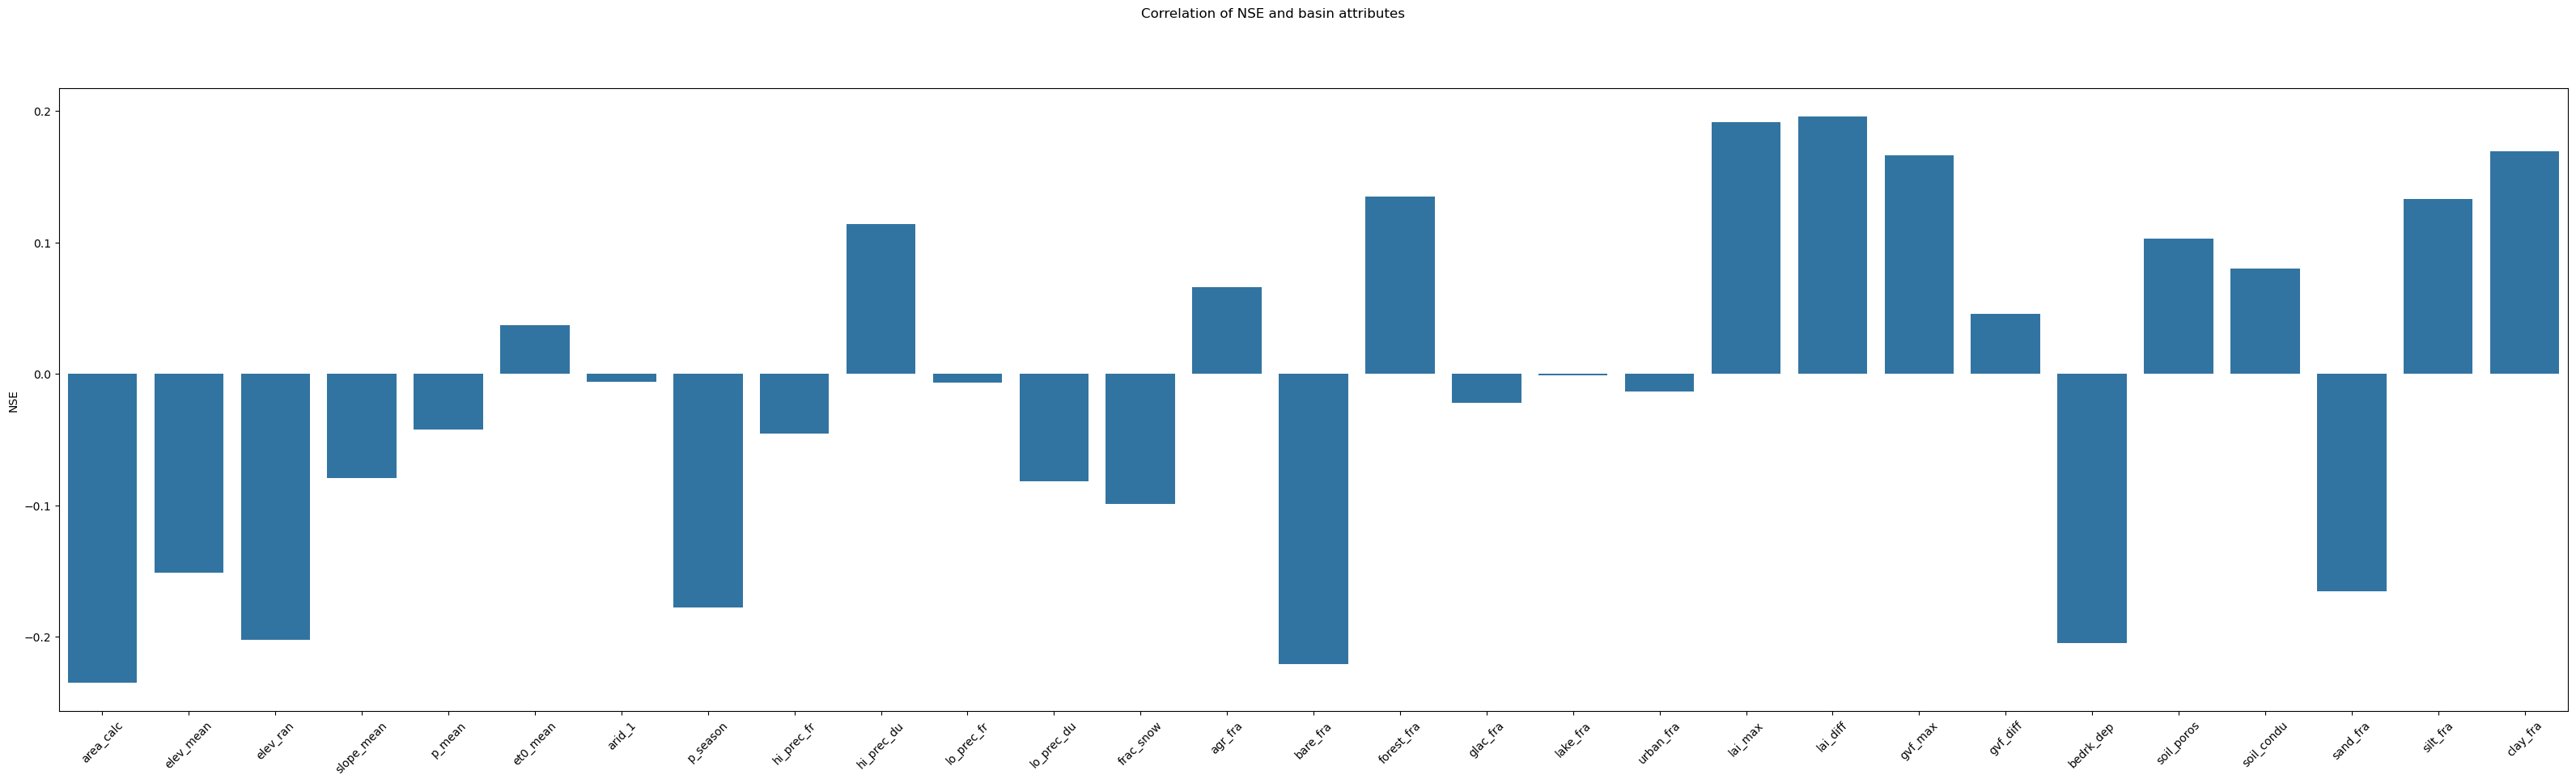

In [189]:
fig, ax = plt.subplots(figsize=(40,10))

sns.barplot(val_set.corr(numeric_only=True).loc["NSE",potential_attributes], ax=ax)
plt.xticks(rotation=45)

fig.suptitle("Correlation of NSE and basin attributes")
fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/test_NSE_attr_correlation.png")


<Axes: xlabel='arid_1', ylabel='NSE'>

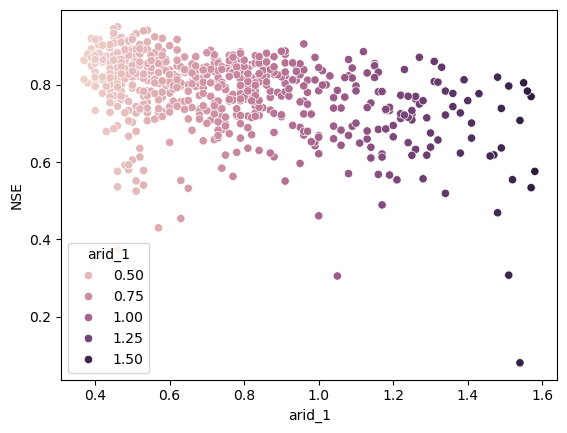

In [179]:
sns.scatterplot(data=train_set[train_set.NSE > 0], x="arid_1", y="NSE", hue="arid_1")

### Tensorboard training history

In [180]:
tb_data_dir = Path("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/tensorboard")
tb_files = list(tb_data_dir.glob("*.csv"))

tb_metrics_dict = {}

for file in tb_files: 

	with open(file, "r") as f: 	
		tb_metrics_dict[file.stem] = pd.read_csv(f)

In [181]:
tb_metrics_dict["valid_loss"]

,Wall time,Step,Value
0,1.773067e+09,1,0.062283
1,1.773070e+09,2,0.063693
2,1.773072e+09,3,0.066707
3,1.773075e+09,4,0.064813
4,1.773077e+09,5,0.062000
5,1.773080e+09,6,0.061252
6,1.773082e+09,7,0.060675
7,1.773085e+09,8,0.061517
8,1.773088e+09,9,0.059294
9,1.773090e+09,10,0.057514


(0.0, 0.1)

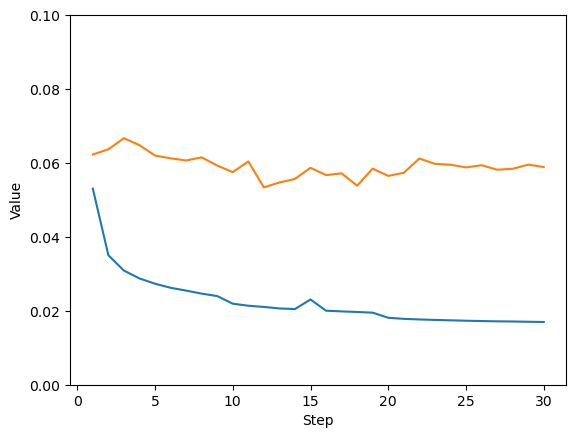

In [182]:
fig, ax = plt.subplots(1)

sns.lineplot(data=tb_metrics_dict["train_loss"], x="Step", y="Value", ax=ax)
sns.lineplot(data=tb_metrics_dict["valid_loss"], x="Step", y="Value", ax=ax)
ax.set_ylim(0,0.1)

(0.4, 1.0)

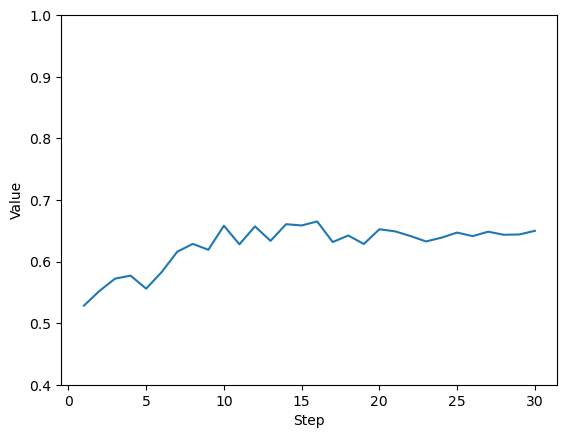

In [183]:
ax = plt.subplot()
sns.lineplot(data=tb_metrics_dict["median_nse"], x="Step", y="Value", ax=ax)
ax.set_ylim(0.4,1)